In [1]:
import os
import pandas as pd

# 데이터 디렉터리 경로
BASE_DIR = './paddy-disease-classification'
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')

# CSV 불러오기
df = pd.read_csv(TRAIN_CSV)

# 데이터 건수와 기본 정보 표시
print(f"data size: {len(df)}")

# 데이터의 앞부분 표시
print(df.head())

# 데이터의 통계 정보 표시
print(df.info())

data size: 10407
     image_id                  label variety  age
0  100330.jpg  bacterial_leaf_blight   ADT45   45
1  100365.jpg  bacterial_leaf_blight   ADT45   45
2  100382.jpg  bacterial_leaf_blight   ADT45   45
3  100632.jpg  bacterial_leaf_blight   ADT45   45
4  101918.jpg  bacterial_leaf_blight   ADT45   45
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10407 entries, 0 to 10406
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  10407 non-null  object
 1   label     10407 non-null  object
 2   variety   10407 non-null  object
 3   age       10407 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 325.3+ KB
None


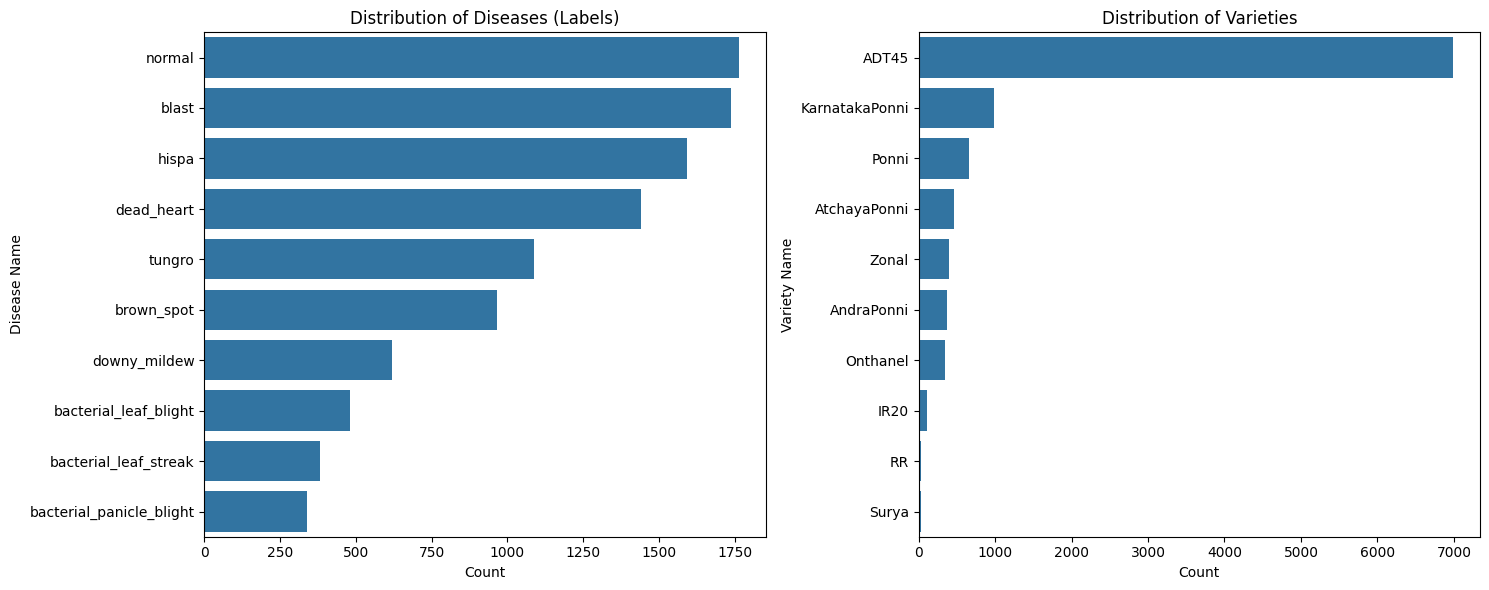

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# 질병 종류 히스토그램
plt.subplot(1, 2, 1)
sns.countplot(y='label', data=df, order=df['label'].value_counts().index)
plt.title('Distribution of Diseases (Labels)')
plt.xlabel('Count')
plt.ylabel('Disease Name')

# 벼 품종(variety) 히스토그램
plt.subplot(1, 2, 2)
sns.countplot(y='variety', data=df, order=df['variety'].value_counts().index)
plt.title('Distribution of Varieties')
plt.xlabel('Count')
plt.ylabel('Variety Name')

plt.tight_layout()
plt.show()

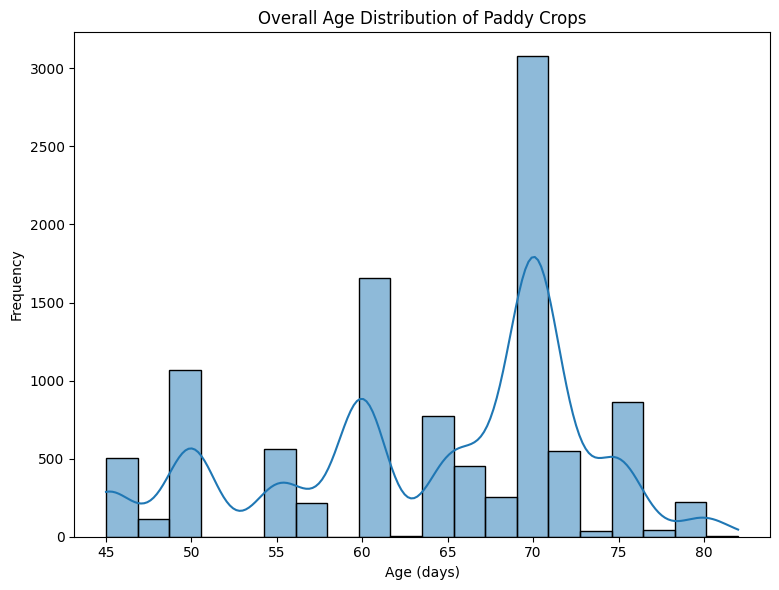

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 생육 일수(age) 히스토그램
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, bins=20)
plt.title('Overall Age Distribution of Paddy Crops')
plt.xlabel('Age (days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

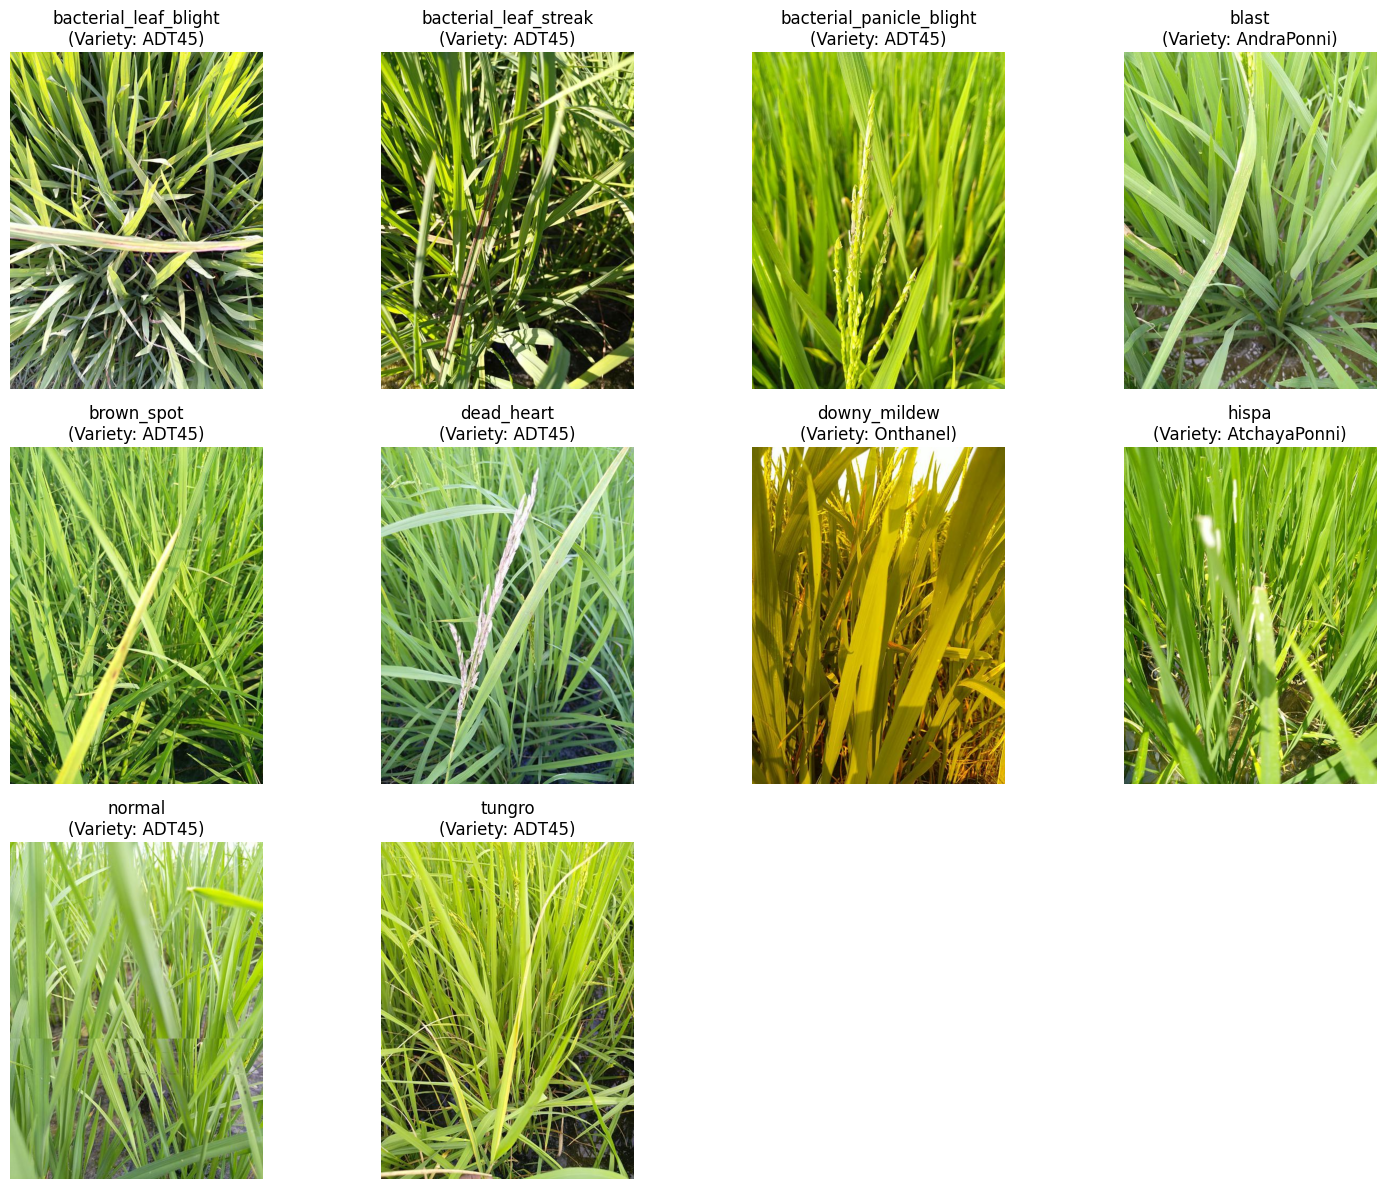

In [4]:
from PIL import Image

# 이미지 전체 경로를 추가하는 함수
def get_image_path(row):
    # train 이미지는 「train_images/라벨명/이미지ID」 폴더 구조입니다
    return os.path.join(BASE_DIR, 'train_images', row['label'], row['image_id'])

# 경로 정보를 DataFrame에 추가
df['path'] = df.apply(get_image_path, axis=1)

# 각 클래스(질병)에서 1장씩 무작위로 골라 표시
unique_labels = df['label'].unique()
plt.figure(figsize=(15, 12))

for i, label in enumerate(unique_labels):
    # 해당 질병 데이터만 추출해 1장을 무작위로 가져옴
    sample_row = df[df['label'] == label].sample(1).iloc[0]
    
    # 이미지 불러오기
    img = Image.open(sample_row['path'])
    
    # 표시
    plt.subplot(3, 4, i + 1) # 3행 4열로 표시
    plt.imshow(img)
    plt.title(f"{label}\n(Variety: {sample_row['variety']})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
!pip install -q timm

import os
import torch

# GPU 사용 가능 여부를 확인한 뒤 변수 device에 저장
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type == 'cuda':
    # 입력 크기가 고정(224x224)이므로 cuDNN 자동 튜닝 활성화
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, 'set_float32_matmul_precision'):
        torch.set_float32_matmul_precision('high')
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu_props.name}")
    print(f"VRAM: {gpu_props.total_memory / 1024**3:.1f} GB")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Using device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.0 GB


In [6]:
### 전처리
import os
import pandas as pd
from sklearn.model_selection import train_test_split

INPUT_DIR = './paddy-disease-classification'
train_df = pd.read_csv(f'{INPUT_DIR}/train.csv')
sample_sub = pd.read_csv(f'{INPUT_DIR}/sample_submission.csv')

# 이미지 경로 생성
train_df['path'] = train_df.apply(lambda x: f"{INPUT_DIR}/train_images/{x['label']}/{x['image_id']}", axis=1)
sample_sub['path'] = sample_sub['image_id'].apply(lambda x: f"{INPUT_DIR}/test_images/{x}")

# 1. 라벨 수치화 (기존)
labels = sorted(train_df['label'].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}
train_df['label_id'] = train_df['label'].map(label2id)

# --- 여기 추가·수정! ---
# 2. 품종 수치화 (variety_id 생성)
varieties = sorted(train_df['variety'].unique())
variety2id = {v: i for i, v in enumerate(varieties)}
# 필요하면 역변환용 사전도 생성
# id2variety = {i: v for i, v in enumerate(varieties)}

train_df['variety_id'] = train_df['variety'].map(variety2id)

# 모델 정의 시 필요한 클래스 수를 저장해 둠
num_varieties = len(varieties)
print(f"Number of varieties: {num_varieties}")
# ------------------------

# 데이터 분할
# variety_id 열을 만든 뒤 분할하면 train/valid 양쪽에 반영됩니다
train_data, valid_data = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['label'], 
    random_state=42
)

print(f"Train data: {len(train_data)}, Valid data: {len(valid_data)}")

Number of varieties: 10
Train data: 8325, Valid data: 2082


In [7]:
### 멀티태스크 학습
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision.transforms.functional import resize as tv_resize

try:
    from torchvision.io import read_image, ImageReadMode
    _HAS_TV_IO = True
except Exception:
    _HAS_TV_IO = False


class FastImageTransform:
    """uint8 CHW 텐서를 Resize + Normalize. DataLoader 워커에서 pickle 가능."""

    def __init__(self, size, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.size = size
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)

    def __call__(self, img):
        img = img.float().div(255.0)
        img = tv_resize(img, [self.size, self.size], antialias=True)
        return (img - self.mean) / self.std


class PaddyDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        # pandas iloc 대신 리스트/배열을 써 데이터 로딩 병목을 줄임
        self.paths = df['path'].tolist()
        self.transform = transform
        self.is_test = is_test
        if not is_test:
            self.targets = df['label_id'].to_numpy(np.int64, copy=False)
            self.varieties = df['variety_id'].to_numpy(np.int64, copy=False)
            self.ages = df['age'].to_numpy(np.float32, copy=False)

    def __len__(self):
        return len(self.paths)

    def _load_image(self, path):
        # 항상 uint8 CHW 텐서로 반환해 transform이 한 종류만 처리하게 함
        if _HAS_TV_IO:
            try:
                return read_image(path, mode=ImageReadMode.RGB)
            except Exception:
                pass
        pil_img = Image.open(path).convert('RGB')
        return torch.from_numpy(np.array(pil_img, copy=True)).permute(2, 0, 1).contiguous()

    def __getitem__(self, idx):
        image = self._load_image(self.paths[idx])

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            # 테스트 시에는 이미지만 반환 (변경 없음)
            return image

        # 학습 시에는 4개 데이터를 반환
        return (
            image,
            int(self.targets[idx]),
            int(self.varieties[idx]),
            float(self.ages[idx]),
        )


IMAGE_SIZE = 224
# IMAGE_SIZE = 320

train_transform = FastImageTransform(IMAGE_SIZE)
val_transform = FastImageTransform(IMAGE_SIZE)
print("Dataset and transform are ready")

Dataset and transform are ready


In [8]:
import os
from torch.utils.data import DataLoader

# Dataset 생성
train_ds = PaddyDataset(train_data, transform=train_transform)
valid_ds = PaddyDataset(valid_data, transform=val_transform)
test_ds = PaddyDataset(sample_sub, transform=val_transform, is_test=True)


def auto_batch_size():
    """VRAM 여유에 맞게 배치 크기를 키워 GPU 이용률을 높입니다."""
    if not torch.cuda.is_available():
        return 32
    mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    if mem_gb >= 20:
        return 256
    if mem_gb >= 12:
        return 192
    if mem_gb >= 8:
        return 128
    if mem_gb >= 6:
        return 96
    if mem_gb >= 4:
        return 64
    return 32


BATCH_SIZE = auto_batch_size()
# Windows Jupyter에서는 num_workers>0이면 첫 배치에서 수분~무한 대기가 발생할 수 있음
NUM_WORKERS = 0
USE_CUDA = torch.cuda.is_available()


def make_loader(dataset, shuffle=False, drop_last=False):
    kwargs = dict(
        dataset=dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=USE_CUDA,
        drop_last=drop_last,
    )
    if NUM_WORKERS > 0:
        kwargs['persistent_workers'] = True
        kwargs['prefetch_factor'] = 4
    return DataLoader(**kwargs)


# DataLoader 생성 (pin_memory + worker prefetch로 GPU 대기 시간 최소화)
train_loader = make_loader(train_ds, shuffle=True, drop_last=True)
valid_loader = make_loader(valid_ds, shuffle=False, drop_last=False)
test_loader = make_loader(test_ds, shuffle=False, drop_last=False)

print(f"DataLoaders are ready. batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS}")

DataLoaders are ready. batch_size=128, num_workers=0


In [9]:
## 오리지널 모델 정의
import timm
import torch.nn as nn
import torch.optim as optim

class PaddyMultiTaskModel(nn.Module):
    def __init__(self, model_name='resnet18', pretrained=True):
        super().__init__()
        
        # 1. 어떤 모델 이름이 와도 분류 헤드 없이(num_classes=0) 로드
        # 이것이 「공통 Backbone」이 됩니다
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        
        # 2. 해당 모델이 출력하는 특징량 차원 수를 자동으로 가져옴
        # 이렇게 하면 ResNet이든 ViT든 코드를 다시 쓸 필요가 없습니다
        n_features = self.backbone.num_features
        
        # 3. 출력층(Head)을 분기
        self.fc_disease = nn.Linear(n_features, 10)  # 질병용
        self.fc_variety = nn.Linear(n_features, 10)  # 품종용
        self.fc_age     = nn.Linear(n_features, 1)   # 생육 일수용

    def forward(self, x):
        features = self.backbone(x)      # 공통 특징 추출
        
        out_d = self.fc_disease(features) # 분기 1
        out_v = self.fc_variety(features) # 분기 2
        out_a = self.fc_age(features)     # 분기 3
        
        return out_d, out_v, out_a

In [10]:
### 모델 호출, 학습 정의 (실제 학습은 다음 셀에서 AMP/배치 최적화로 다시 생성합니다)
# 모델 인스턴스화
model = PaddyMultiTaskModel(model_name='resnet18')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 손실 함수 정의
criterion_disease = nn.CrossEntropyLoss()
criterion_variety = nn.CrossEntropyLoss()
criterion_age = nn.MSELoss() # 회귀이므로 MSE 등

In [11]:
import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast
from tqdm.notebook import tqdm

### 모델 호출, 학습 정의
# 모델 인스턴스화
model = PaddyMultiTaskModel(model_name='resnet18')

# DataParallel은 작은 모델에서 통신 오버헤드가 커서 이용률이 떨어지므로 사용하지 않음
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type == "cuda"
if use_cuda:
    model = model.to(device, memory_format=torch.channels_last)
else:
    model = model.to(device)

try:
    optimizer = optim.Adam(model.parameters(), lr=1e-3, fused=use_cuda)
except (TypeError, RuntimeError):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 손실 함수 정의
criterion_disease = nn.CrossEntropyLoss()
criterion_variety = nn.CrossEntropyLoss()
criterion_age = nn.MSELoss()  # 회귀이므로 MSE 등

# mixed precision: Tensor Core 활용 + 메모리 절약으로 큰 배치가 가능
scaler = GradScaler('cuda', enabled=use_cuda)

# --- 하이퍼파라미터 설정 ---
epochs = 5  # 추이를 보기 위해 조금 늘려도 됨
WEIGHT_V = 0.05
WEIGHT_A = 0.0  # 생육 일수도 조금 학습시키는 편이 효과적인 경우가 많아 0.1로 설정(임의)

# 최고 정확도를 기록할 변수를 초기화
best_acc = 0.0
save_path = "best_model.pth"

print(f"Start Training for {epochs} epochs... (AMP={use_cuda}, batch_size={BATCH_SIZE})")

for epoch in range(epochs):
    # ==============================
    # 1. Training Phase
    # ==============================
    model.train()  # 학습 모드
    train_loss = torch.zeros((), device=device)

    # 프로그레스 바 설정
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for step, (images, targets, varieties, ages) in enumerate(pbar, 1):
        if use_cuda:
            images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            images = images.to(device)
        targets = targets.to(device, non_blocking=use_cuda)
        varieties = varieties.to(device, non_blocking=use_cuda)
        ages = ages.to(device, non_blocking=use_cuda).float()

        optimizer.zero_grad(set_to_none=True)

        # 멀티태스크 출력 + 개별/통합 Loss (AMP)
        with autocast('cuda', enabled=use_cuda):
            out_disease, out_variety, out_age = model(images)
            loss_d = criterion_disease(out_disease, targets)
            loss_v = criterion_variety(out_variety, varieties)
            loss_a = criterion_age(out_age.view(-1), ages)
            loss = loss_d + (WEIGHT_V * loss_v) + (WEIGHT_A * loss_a)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.detach().float()

        # GPU-CPU 동기화를 줄이기 위해 20스텝마다만 표시
        if step % 20 == 0:
            pbar.set_postfix({'loss': float(loss.detach())})

    # 에포크별 평균 Loss (에포크당 1회만 CPU로 가져옴)
    avg_train_loss = (train_loss / len(train_loader)).item()

    # ==============================
    # 2. Validation Phase
    # ==============================
    model.eval()  # 추론 모드 (Dropout 등을 비활성화)
    correct_counts = torch.zeros((), device=device, dtype=torch.long)
    total_counts = 0

    # 검증 시에는 기울기 계산 불필요 (메모리 절약·속도 향상)
    with torch.inference_mode():
        for images, targets, varieties, ages in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]", leave=False):
            if use_cuda:
                images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                images = images.to(device)
            targets = targets.to(device, non_blocking=use_cuda)

            # 추론 (테스트 시에는 질병 정확도만 보면 됨)
            with autocast('cuda', enabled=use_cuda):
                out_disease, _, _ = model(images)
            predicted = out_disease.argmax(1)

            total_counts += targets.size(0)
            correct_counts += (predicted == targets).sum()

    # 정확도 계산
    val_acc = correct_counts.item() / total_counts

    # ==============================
    # 3. Log & Save Best Model
    # ==============================
    print(f"Epoch {epoch+1} Result:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Valid Acc : {val_acc:.4f} ({val_acc*100:.2f}%)")

    # 과거 최고 정확도가 나오면 모델 저장
    if val_acc > best_acc:
        print(f"  [Create Best Model] Accuracy improved from {best_acc:.4f} to {val_acc:.4f}. Saving model...")
        best_acc = val_acc
        torch.save(model.state_dict(), save_path)
    else:
        print(f"  Accuracy did not improve from {best_acc:.4f}.")

    print("-" * 30)

print("Training Finished.")
print(f"Best Validation Accuracy: {best_acc:.4f}")

# RTX 3060 12G 약 10분 소요

Start Training for 5 epochs... (AMP=True, batch_size=128)


Epoch 1/5 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 1 Result:
  Train Loss: 1.3874
  Valid Acc : 0.7685 (76.85%)
  [Create Best Model] Accuracy improved from 0.0000 to 0.7685. Saving model...
------------------------------


Epoch 2/5 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

...

Epoch 4/5 [Valid]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 4 Result:
  Train Loss: 0.0482
  Valid Acc : 0.9207 (92.07%)
  Accuracy did not improve from 0.9289.
------------------------------


Epoch 5/5 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 5 Result:
  Train Loss: 0.0322
  Valid Acc : 0.9251 (92.51%)
  Accuracy did not improve from 0.9289.
------------------------------
Training Finished.
Best Validation Accuracy: 0.9289


In [12]:
import torch
from torch.amp import autocast
from tqdm.notebook import tqdm

# 1. 모델 가중치 로드
# ※ map_location=device를 지정하면 GPU에서 저장한 모델을 CPU에서 읽을 때 등의 오류를 방지합니다
print("Loading best model weights...")
try:
    state_dict = torch.load("best_model.pth", map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load("best_model.pth", map_location=device)

# 이전에 DataParallel로 저장한 체크포인트도 로드 가능하게 처리
if any(k.startswith('module.') for k in state_dict):
    state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}

model.load_state_dict(state_dict)

# 2. 추론 모드로 설정
model.eval()
preds = []
use_cuda = device.type == 'cuda'

print("Predicting...")
with torch.inference_mode():
    for images in tqdm(test_loader):
        if use_cuda:
            images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            images = images.to(device)

        # 멀티태스크 모델이므로 반환값이 3개임에 주의 (질병, 품종, 생육 일수)
        # 필요한 것은 첫 번째 「질병(outputs)」뿐입니다
        with autocast('cuda', enabled=use_cuda):
            outputs, _, _ = model(images)

        # 확률이 가장 큰 클래스 ID를 가져옴
        predicted = outputs.argmax(1)
        preds.extend(predicted.cpu().numpy())

# 결과를 정리
sample_sub['label'] = [id2label[i] for i in preds]
submission = sample_sub[['image_id', 'label']]
submission.to_csv('submission.csv', index=False)

print("Saved submission.csv!")
print(submission.head())

Loading best model weights...
Predicting...


  0%|          | 0/28 [00:00<?, ?it/s]

Saved submission.csv!
     image_id   label
0  200001.jpg   hispa
1  200002.jpg  normal
2  200003.jpg   blast
3  200004.jpg   blast
4  200005.jpg   blast


In [13]:
!ls

'ls'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
